In [1]:
from pathlib import Path

In [2]:
tif_files = list(
    Path("../data/raw/terrain").rglob("*.tif")
)

print(f"Number of tif files: {len(tif_files)}")

for f in tif_files[:10]:
    print(f)

Number of tif files: 2
..\data\raw\terrain\output_hh.tif
..\data\raw\terrain\output_hh_1.tif


Checks before merging

In [3]:
import rasterio

In [5]:
tif_files = list(
    Path("../data/raw/terrain").rglob("*.tif")
)

for tif in tif_files:
    with rasterio.open(tif) as src:
        print(f"\nFile: {tif.name}")
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolution:", src.res)
        print("Shape", (src.height, src.width))


File: output_hh.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-8.700138899999985, bottom=49.80013889999999, right=-3.0001388999999845, top=60.900138899999995)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Shape (39960, 20520)

File: output_hh_1.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-3.000138899999996, bottom=49.80013889999999, right=2.499861100000004, top=60.900138899999995)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Shape (39960, 19800)


In [6]:
from rasterio.merge import merge

src_files = [
    rasterio.open(f)
    for f in tif_files
]

mosaic, transform = merge(src_files)

print(mosaic.shape)

(1, 39960, 40320)


In [9]:
out_meta = src_files[0].meta.copy()

out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

with rasterio.open(
    "../data/interim/terrain_processed/uk_dem.tif",
    "w",
    **out_meta
) as dest:
    dest.write(mosaic)

In [11]:
with rasterio.open(
    "../data/interim/terrain_processed/uk_dem.tif"
) as dem:

    print("CRS", dem.crs)
    print("Bounds:", dem.bounds)
    print("Resolution:", dem.res)
    print("shape", (dem.height, dem.width))

CRS EPSG:4326
Bounds: BoundingBox(left=-8.700138899999985, bottom=49.80013889999999, right=2.4998611000000146, top=60.900138899999995)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
shape (39960, 40320)


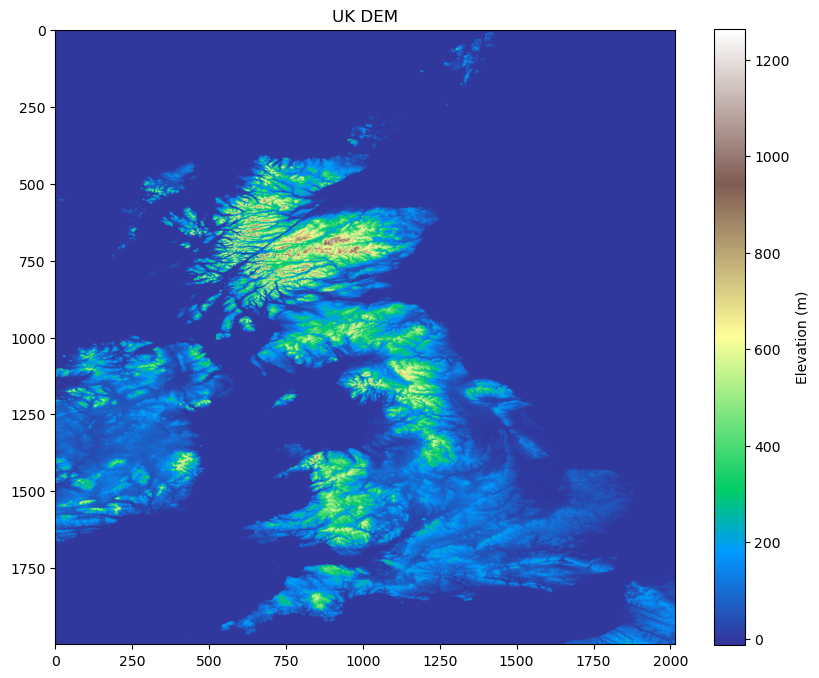

In [15]:
import matplotlib.pyplot as plt
from rasterio.enums import Resampling


with rasterio.open(
    "../data/interim/terrain_processed/uk_dem.tif"
) as dem:
    elevation = dem.read(
        1,
        out_shape =(
            int(dem.height/20),
            int(dem.width/20)
        ),
        resampling =Resampling.average
    )

plt.figure(figsize=(10,8))
plt.imshow(elevation, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("UK DEM")
plt.show()


In [16]:
with rasterio.open(
    "../data/interim/terrain_processed/uk_dem.tif"
) as dem:

    print("CRS:", dem.crs)
    print("Bounds:", dem.bounds)
    print("Resoultion", dem.res)
    print("Width:", dem.width)
    print("Height:", dem.height)

CRS: EPSG:4326
Bounds: BoundingBox(left=-8.700138899999985, bottom=49.80013889999999, right=2.4998611000000146, top=60.900138899999995)
Resoultion (0.0002777777777777778, 0.0002777777777777778)
Width: 40320
Height: 39960
